In [1]:
import os
import scipy
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import geopandas as gpd
import statsmodels.api as sm
import ipywidgets as widgets
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display, clear_output

In [ ]:
!wget "https://github.com/flaviovdf/fcd/raw/refs/heads/main/projeto/data_20251/real_data_fcd.zip" -P ./

caminho_zip = './real_data_fcd.zip'
caminho_destino = './data_fcd/'  # Pasta onde os arquivos serão extraídos

# Se já existe a pasta, apaga ela primeiro (para garantir substituição completa)
if os.path.exists(caminho_destino):
    shutil.rmtree(caminho_destino)

# Cria a pasta destino novamente
os.makedirs(caminho_destino, exist_ok=True)

# Descompacta mantendo estrutura
!unzip -q {caminho_zip} -d {caminho_destino}
!rm {caminho_zip}

In [3]:
!sed -i 's/,/./g' './data_fcd/indicadores/ibge_desemprego.csv'
!sed -i 's/,/./g' './data_fcd/indicadores/ibge_populacao.csv'
!sed -i 's/,/./g' './data_fcd/indicadores/ibge_pib.csv'
!sed -i 's/,/./g' './data_fcd/indicadores/ibge_sim.csv'

In [ ]:
indicadores = {}

for data in os.listdir("../FCD/data_fcd/indicadores/"):
    path = f"../FCD/data_fcd/indicadores/{data}"
    if os.path.isfile(path) and data.endswith('.csv'):
        nome_indicador = os.path.splitext(data)[0]
        df = pd.read_csv(path, sep=';')

        # Separar a coluna 'Municipio' em ID (6 dígitos) e Nome do município
        df[['ID', 'Nome_Mun']] = df['Municipio'].str.extract(r'(\d{6})\s+(.*)', expand=True)

        # Garantir que o ID seja string
        df['ID'] = df['ID'].astype(str)

        # Remover a coluna antiga 'Municipio' já que agora temos ID e Nome separados
        df.drop(columns=['Municipio'], inplace=True)

        # Salvar o dataframe processado
        indicadores[nome_indicador] = df

        print(f"Indicador: {nome_indicador} -> Colunas: {df.columns.tolist()[:5]}")

# Exemplo pra ver se está certo
print("Exemplo do indicador ibge_desemprego:")
print(indicadores['ibge_desemprego'].head())

In [5]:
# Função auxiliar para pegar código da UF
def sigla_to_cod(sigla):
    sigla = sigla.lower()
    uf_codigos = {
        'ro': '11', 'ac': '12', 'am': '13', 'rr': '14', 'pa': '15', 'ap': '16', 'to': '17',
        'ma': '21', 'pi': '22', 'ce': '23', 'rn': '24', 'pb': '25', 'pe': '26', 'al': '27', 'se': '28', 'ba': '29',
        'mg': '31', 'es': '32', 'rj': '33', 'sp': '35',
        'pr': '41', 'sc': '42', 'rs': '43',
        'ms': '50', 'mt': '51', 'go': '52', 'df': '53'
    }
    return uf_codigos[sigla]
    
# Função auxiliar para pegar UF do código
def codigo_para_estado(cod):
    uf_estado = {
        '11': 'ro', '12': 'ac', '13': 'am', '14': 'rr', '15': 'pa', '16': 'ap', '17': 'to',
        '21': 'ma', '22': 'pi', '23': 'ce', '24': 'rn', '25': 'pb', '26': 'pe', '27': 'al', '28': 'se', '29': 'ba',
        '31': 'mg', '32': 'es', '33': 'rj', '35': 'sp',
        '41': 'pr', '42': 'sc', '43': 'rs',
        '50': 'ms', '51': 'mt', '52': 'go', '53': 'df'
    }
    return uf_estado[cod].upper()

# Função auxiliar para pegar código UF a partid do Município
def estadoID(ID):
    return ID[:2]

# Função padronizadora
def padroniza(col):
    return abs((col - col.mean()) / np.std(col))

# Função normalizadora
def normaliza(col):
    return (col - col.min()) / (col.max() - col.min())


# Dicionário com colunas e nomes bonitos
coluna_por_indicador = {
    'ibge_sim': 'Obitos',
    'ibge_populacao': 'Populacao_residente',
    'ibge_desemprego': 'Taxa_de_desemprego.',
    'ibge_pib': 'Produto_interno_bruto_(PIB).'
}

nomes_bonitos = {
    'ibge_pib': 'PIB',
    'ibge_sim': 'Óbitos',
    'ibge_populacao': 'População',
    'ibge_desemprego': 'Desemprego (%)'
}

siglas_estados = [
    'ac', 'al', 'am', 'ap', 'ba', 'ce', 'df', 'es', 'go',
    'ma', 'mg', 'ms', 'mt', 'pa', 'pb', 'pe', 'pi', 'pr',
    'rj', 'rn', 'ro', 'rr', 'rs', 'sc', 'se', 'sp', 'to'
]

In [6]:
#Função para carregar o mapa do estado com indicador
def carregar_estado_mapa(sigla_estado, nome_indicador):
    coluna_indicador = coluna_por_indicador[nome_indicador]
    df_indicador = indicadores[nome_indicador]

    pasta_estado = f'../FCD/data_fcd/dados_geograficos/{sigla_estado}_municipios/'
    arquivos_shp = [f for f in os.listdir(pasta_estado) if f.endswith('.shp')]
    if not arquivos_shp:
        print(f"Nenhum shapefile encontrado para {sigla_estado.upper()}")
        return None
    arquivo_shp = arquivos_shp[0]
    caminho_shp = os.path.join(pasta_estado, arquivo_shp)

    mapa = gpd.read_file(caminho_shp)
    mapa['cod6'] = mapa['CD_GEOCODM'].str[:6]

    df_indicador_filtered = df_indicador[df_indicador['ID'].isin(mapa['cod6'])]
    mapa_indicador = mapa.merge(df_indicador_filtered, left_on='cod6', right_on='ID', how='left')

    return mapa_indicador

# Função para plotar o estado
def plot_estado_indicador(sigla_estado, nome_indicador):
    mapa_indicador = carregar_estado_mapa(sigla_estado, nome_indicador)
    if mapa_indicador is None:
        return

    coluna_indicador = coluna_por_indicador[nome_indicador]

    plt.figure(figsize=(8, 6))
    mapa_indicador.plot(
        column=coluna_indicador,
        cmap='magma_r',
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Sem dado"},
        edgecolor='black',
        linewidth=0.3
    )
    plt.title(f"{sigla_estado.upper()} - {nomes_bonitos[nome_indicador]}")
    plt.axis('off')
    plt.show()

# Função para plotar o Brasil inteiro
brasil_mapa = None

def plot_brasil_indicador(nome_indicador):
    global brasil_mapa
    gdfs_estados = []
    coluna_indicador = coluna_por_indicador[nome_indicador]
    df_indicador = indicadores[nome_indicador]

    for sigla in tqdm(siglas_estados, desc="Carregando estados para mapa Brasil"):
        mapa_indicador = carregar_estado_mapa(sigla, nome_indicador)
        if mapa_indicador is not None:
            gdfs_estados.append(mapa_indicador)

    brasil_mapa = pd.concat(gdfs_estados, ignore_index=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    brasil_mapa.plot(
        column=coluna_indicador,
        cmap='magma_r',
        legend=True,
        edgecolor="k",
        linewidth=0.1,
        missing_kwds={"color": "lightgrey", "label": "Sem dado"},
        ax=ax
    )

    ax.set_title(f"Brasil - {nomes_bonitos[nome_indicador]}")
    ax.axis('off')
    plt.show()

In [7]:
# Widgets para Estados
estado_widget = widgets.Dropdown(
    options=siglas_estados,
    value='mg',
    description='Estado:',
)

indicador_widget = widgets.Dropdown(
    options=list(coluna_por_indicador.keys()),
    value='ibge_sim',
    description='Indicador:',
)

ui_estado = widgets.HBox([estado_widget, indicador_widget])

out_estado = widgets.interactive_output(
    plot_estado_indicador,
    {'sigla_estado': estado_widget, 'nome_indicador': indicador_widget}
)

display(ui_estado, out_estado)


Output()

In [8]:
# Widget para Brasil
indicador_brasil_widget = widgets.Dropdown(
    options=list(coluna_por_indicador.keys()),
    value='ibge_sim',
    description='Indicador:',
)

ui_brasil = widgets.HBox([indicador_brasil_widget])

out_brasil = widgets.interactive_output(
    plot_brasil_indicador,
    {'nome_indicador': indicador_brasil_widget}
)

display(ui_brasil, out_brasil)

Output()

In [9]:
df[df['ID'] != 110002]

,Taxa_de_desemprego.,ID,Nome_Mun
0,5.10,110001,ALTA FLORESTA D'OESTE
1,4.64,110002,ARIQUEMES
2,2.49,110003,CABIXI
3,5.87,110004,CACOAL
4,5.24,110005,CEREJEIRAS
...,...,...,...
5544,3.44,522200,VIANOPOLIS
5545,5.66,522205,VICENTINOPOLIS
5546,8.16,522220,VILA BOA
5547,2.71,522230,VILA PROPICIO


> # Tarefa 2: Gráficos de Barra para os Indicadores

>$A)$

<Axes: title={'center': 'Taxa de Desemprego por Estado'}, xlabel='ID_Estado'>

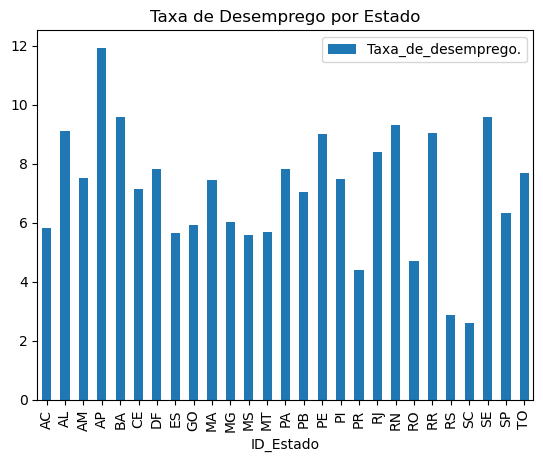

In [10]:
Desemprego_Estado = indicadores['ibge_desemprego'].assign(ID_Estado = indicadores['ibge_desemprego']['ID'].apply(estadoID).apply(codigo_para_estado))
Desemprego_Estado.get(['Taxa_de_desemprego.', 'ID_Estado']).groupby('ID_Estado').mean().plot(kind = 'bar',title = 'Taxa de Desemprego por Estado')

>$B)$

<Axes: ylabel='Nome_Mun'>

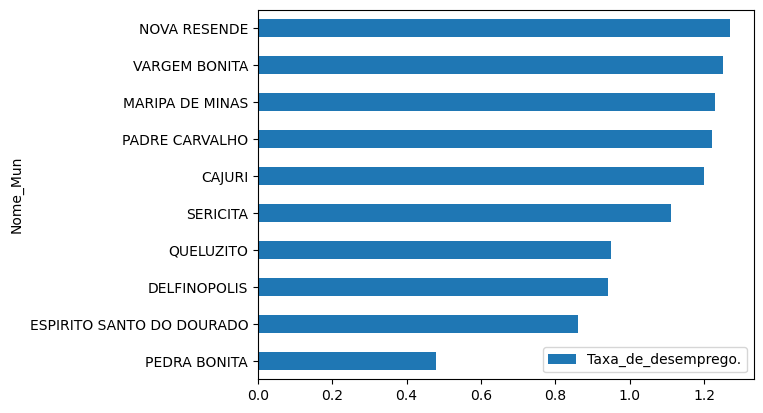

In [11]:
(Desemprego_Estado[Desemprego_Estado['ID_Estado'] == 'MG'].sort_values(by = "Taxa_de_desemprego.")[:10].
 plot(kind = 'barh', x = 'Nome_Mun'))

<Axes: ylabel='Nome_Mun'>

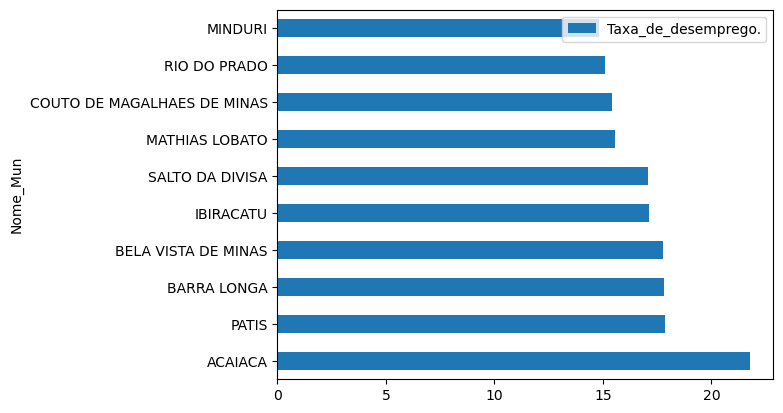

In [12]:
(Desemprego_Estado[Desemprego_Estado['ID_Estado'] == 'MG'].sort_values(by = "Taxa_de_desemprego.", ascending = False)[:10].
 plot(kind = 'barh', x = 'Nome_Mun'))

>$C)$

In [13]:
estado_widget = widgets.Dropdown(
    options=siglas_estados,
    value='mg',
    description='Estado:',
)

indicador_widget = widgets.Dropdown(
    options=list(coluna_por_indicador.keys()),
    value='ibge_desemprego',
    description='Indicador:',
)

ui_estado = widgets.HBox([estado_widget, indicador_widget])

out_estado = widgets.interactive_output(
    plot_estado_indicador,
    {'sigla_estado': estado_widget, 'nome_indicador': indicador_widget}
)

display(ui_estado, out_estado)

Output()

> # Tarefa 3: Comparando Capitais 

In [14]:
ids_capitais = [
    '120040',  # Rio Branco (AC)
    '160030',  # Macapá (AP)
    '130260',  # Manaus (AM)
    '172100',  # Palmas (TO)
    '110020',  # Porto Velho (RO)
    '140010',  # Boa Vista (RR)
    '150140',  # Belém (PA)
    '211130',  # São Luís (MA)
    '221100',  # Teresina (PI)
    '230440',  # Fortaleza (CE)
    '240810',  # Natal (RN)
    '250750',  # João Pessoa (PB)
    '261160',  # Recife (PE)
    '270430',  # Maceió (AL)
    '280030',  # Aracaju (SE)
    '292740',  # Salvador (BA)
    '510340',  # Cuiabá (MT)
    '500270',  # Campo Grande (MS)
    '520870',  # Goiânia (GO)
    '530010',  # Brasília (DF)
    '355030',  # São Paulo (SP)
    '330455',  # Rio de Janeiro (RJ)
    '310620',  # Belo Horizonte (MG)
    '320530',  # Vitória (ES)
    '410690',  # Curitiba (PR)
    '420540',  # Florianópolis (SC)
    '431490'   # Porto Alegre (RS)
]



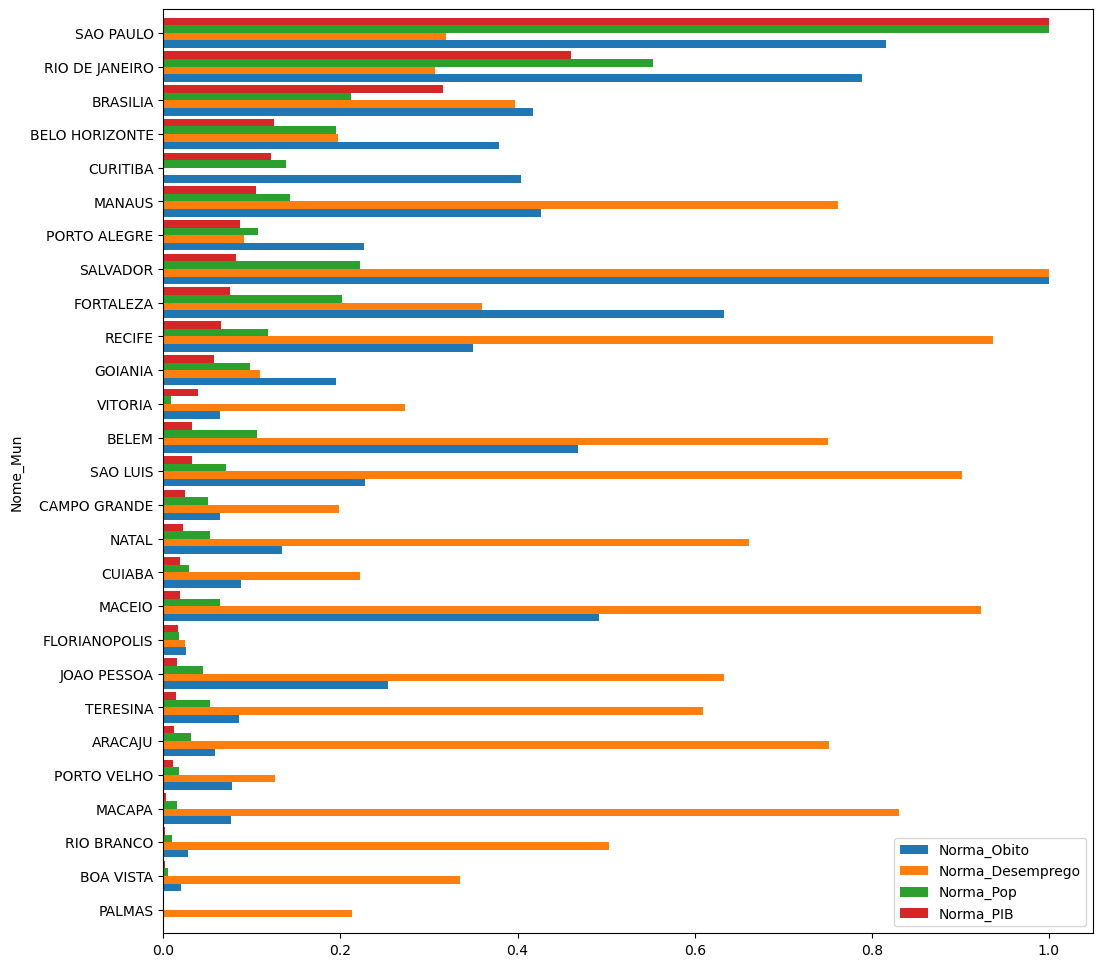

In [15]:
obito_capitais = indicadores['ibge_sim'][indicadores['ibge_sim']['ID'].isin(ids_capitais)]
desemprego_capitais = indicadores['ibge_desemprego'][indicadores['ibge_desemprego']['ID'].isin(ids_capitais)]
pop_capitais = indicadores['ibge_populacao'][indicadores['ibge_populacao']['ID'].isin(ids_capitais)]
pib_capitais = indicadores['ibge_pib'][indicadores['ibge_pib']['ID'].isin(ids_capitais)]

# Normalizando os indicadores #
obito_capitais_nor = obito_capitais.assign(Norma_Obito = normaliza(obito_capitais['Obitos'])).drop(columns = 'Obitos')
desemprego_capitais_nor = desemprego_capitais.assign(Norma_Desemprego = normaliza(desemprego_capitais['Taxa_de_desemprego.'])).drop(columns = 'Taxa_de_desemprego.')
pop_capitais_nor = pop_capitais.assign(Norma_Pop = normaliza(pop_capitais['Populacao_residente'])).drop(columns = 'Populacao_residente')
pib_capitais_nor = pib_capitais.assign(Norma_PIB = normaliza(pib_capitais['Produto_interno_bruto_(PIB).'])).drop(columns = 'Produto_interno_bruto_(PIB).')

x = obito_capitais_nor.merge(desemprego_capitais_nor).merge(pop_capitais_nor).merge(pib_capitais_nor).sort_values(by = 'Norma_PIB').plot(kind = 'barh', x = 'Nome_Mun', figsize = (12, 12), width=0.9)

># Tarefa 4: Discretizando Dados no Mapa

In [16]:
def cor (col):
    if col <= categorias[1] and col > categorias[0]:
        return '#FFFF33'
    elif col <= categorias[2] and col > categorias[1]:
        return '#FF00FF'
    elif col <= categorias[3] and col > categorias[2]:
        return '#13F650'
    elif col <= categorias[4] and col > categorias[3]:
        return '#F61313'

In [17]:
obitos_SP_escala = indicadores['ibge_sim'].assign(Estado = indicadores['ibge_sim']['ID'].apply(estadoID).apply(codigo_para_estado))
obitos_SP_escala = obitos_SP_escala[obitos_SP_escala['Estado'] == 'SP']
obitos_SP_escala = obitos_SP_escala.assign(Obitos_Esc = np.log1p(obitos_SP_escala['Obitos'])).drop(columns = 'Obitos')

In [18]:
import matplotlib.patches as mpatches
categorias = np.arange(0, 7.41, 1.85)
cores_categorias = {
    '0': '#FFFF33',
    '1': '#FF00FF',
    '2': '#13F650',
    '3': '#F61313',
    'Sem dados': 'lightgrey'
}
legenda = [
    mpatches.Patch(color=cor, label=f'Categoria {cat}')
    for cat, cor in cores_categorias.items()
]
obitos_SP_escala = obitos_SP_escala.assign(Cor = obitos_SP_escala['Obitos_Esc'].apply(cor))

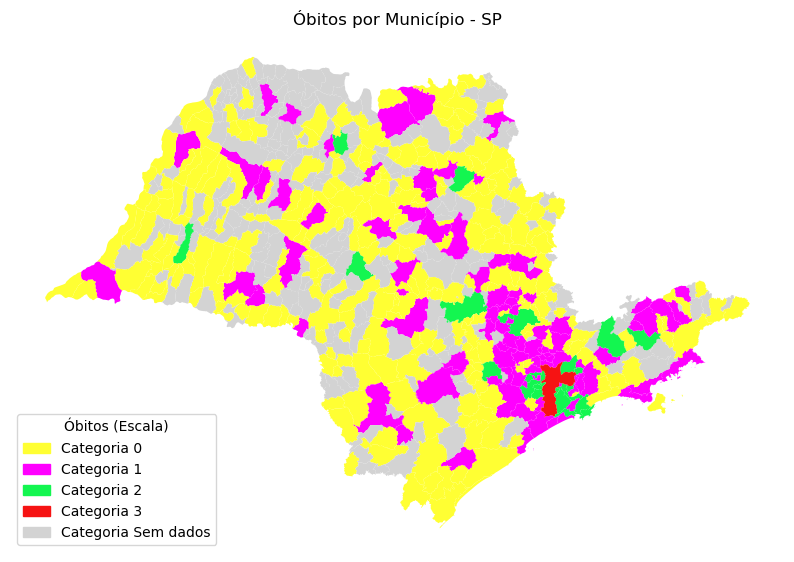

In [19]:
pasta_estado = f'../FCD/data_fcd/dados_geograficos/sp_municipios/'
arquivo_shp = [f for f in os.listdir(pasta_estado) if f.endswith('.shp')][0]
caminho_shp = os.path.join(pasta_estado, arquivo_shp)
mapa = gpd.read_file(caminho_shp)
mapa['cod6'] = mapa['CD_GEOCODM'].str[:6]
mapa_obitos = mapa.merge(obitos_SP_escala, left_on='cod6', right_on='ID', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
mapa_obitos['Cor'] = mapa_obitos['Cor'].fillna('lightgrey')
mapa_obitos.plot(color = mapa_obitos['Cor'], ax=ax)
plt.title("Óbitos por Município - SP")
plt.axis('off')
plt.legend(handles=legenda, title='Óbitos (Escala)', loc='lower left')
plt.show()

> # Tarefa 5: Análise dos 10 municípios com maior indicador ibge_sim

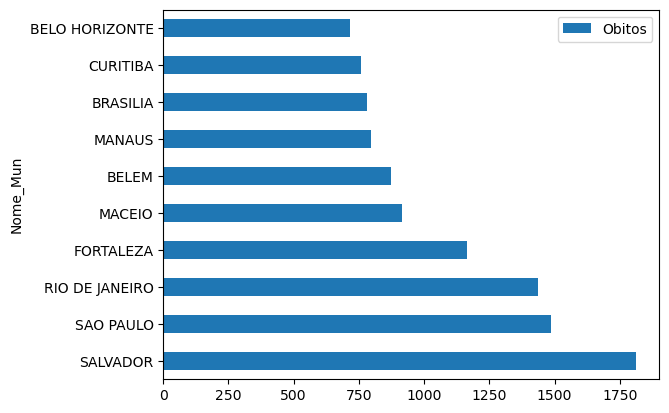

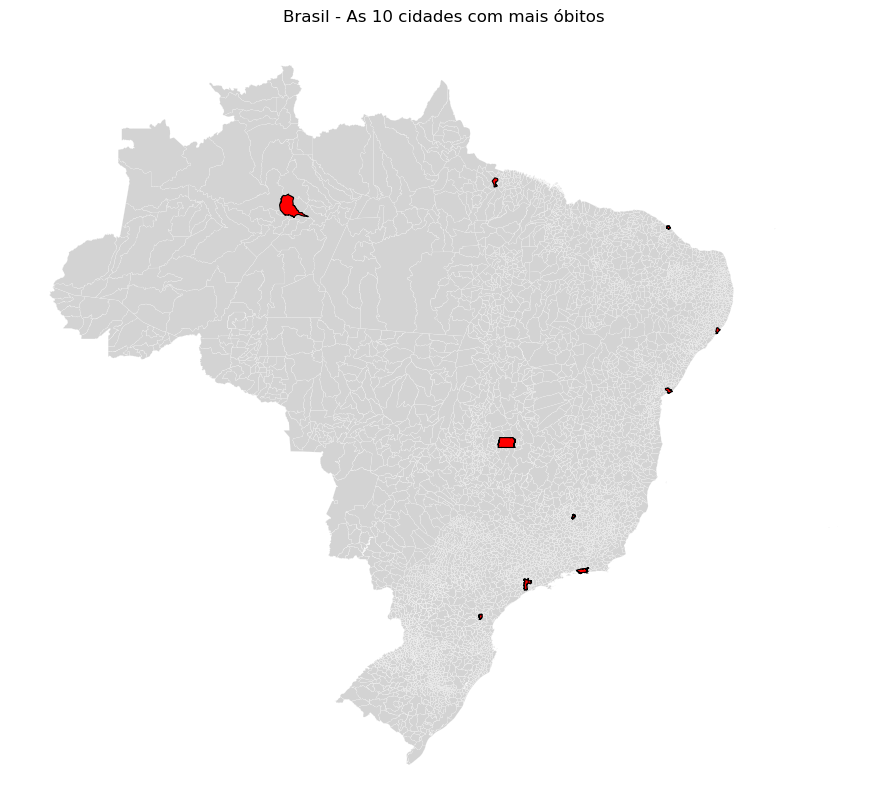

In [20]:
Top_10_Obitos = indicadores['ibge_sim'].sort_values(by = 'Obitos', ascending = False)[:10]
indicadores['ibge_sim'].sort_values(by = 'Obitos', ascending = False)[:10].plot(kind = 'barh', x = 'Nome_Mun')

fig, ax = plt.subplots(figsize=(12, 10))
brasil_mapa.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.1)
brasil_mapa[brasil_mapa['cod6'].isin(Top_10_Obitos['ID'])].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.8,
)

ax.set_title(f"Brasil - As 10 cidades com mais óbitos")
ax.axis('off')
plt.show()

> # Tarefa 6: vamos brincar de regressão #
> 

>$A)$                     
>$B)$

In [21]:
import statsmodels.api as sm

In [22]:
Pib_Obito = indicadores['ibge_sim'].merge(indicadores['ibge_pib'])
Pib_Obito = Pib_Obito.assign(Estado = Pib_Obito['ID'].apply(estadoID).apply(codigo_para_estado))

Pop_Obito = indicadores['ibge_sim'].merge(indicadores['ibge_populacao'])
Pop_Obito = Pop_Obito.assign(Estado = Pop_Obito['ID'].apply(estadoID).apply(codigo_para_estado))

r_Pib_Obito = Pib_Obito['Obitos'].corr(Pib_Obito['Produto_interno_bruto_(PIB).'])
r_Pop_Obito = Pop_Obito['Obitos'].corr(Pop_Obito['Populacao_residente'])

<Axes: title={'center': ' População por Óbito - SC '}, xlabel='Populacao_residente', ylabel='Obitos'>

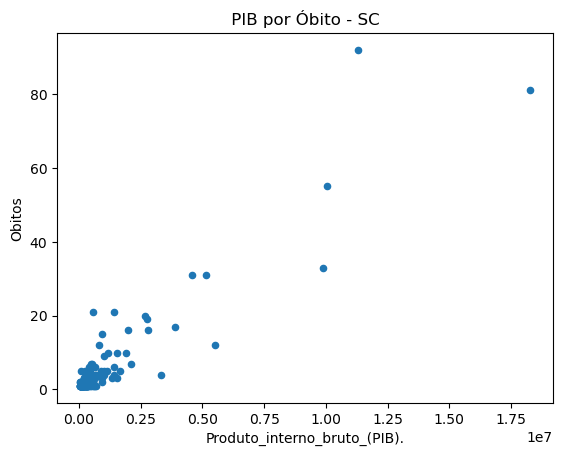

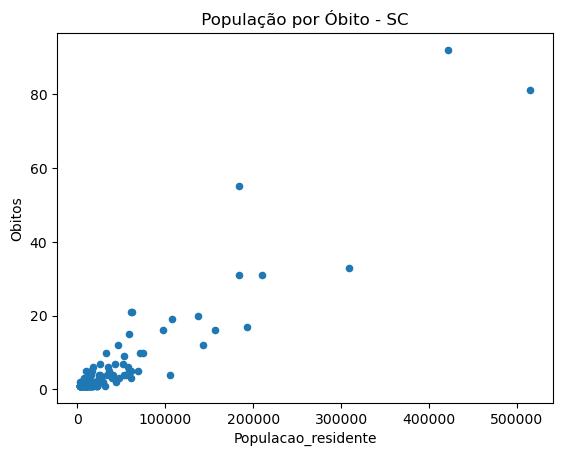

In [23]:
Pib_Obito_SC = Pib_Obito[Pib_Obito['Estado'] == 'SC']
Pib_Obito_SC.plot(kind = 'scatter', x = 'Produto_interno_bruto_(PIB).', y = 'Obitos', title = ' PIB por Óbito - SC ') 

Pop_Obito_SC = Pop_Obito[Pop_Obito['Estado'] == 'SC']
Pop_Obito_SC.plot(kind = 'scatter', x = 'Populacao_residente', y = 'Obitos', title = ' População por Óbito - SC ') 

<Axes: title={'center': ' População por Óbito - ES '}, xlabel='Populacao_residente', ylabel='Obitos'>

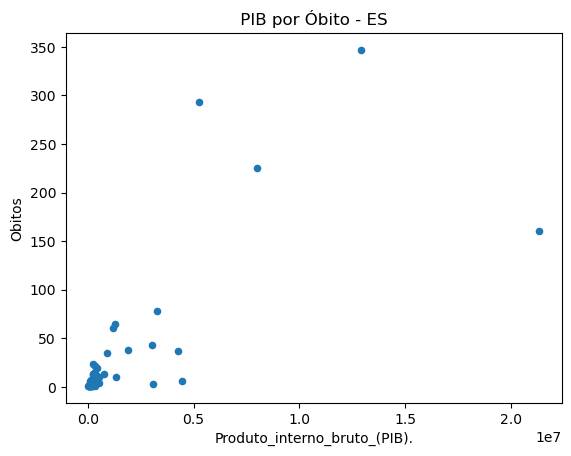

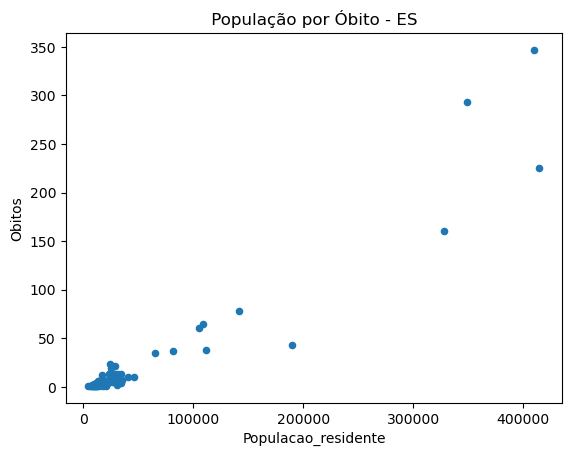

In [24]:
Pib_Obito_ES = Pib_Obito[Pib_Obito['Estado'] == 'ES']
Pib_Obito_ES.plot(kind = 'scatter', x = 'Produto_interno_bruto_(PIB).', y = 'Obitos', title = ' PIB por Óbito - ES ') 

Pop_Obito_ES = Pop_Obito[Pop_Obito['Estado'] == 'ES']
Pop_Obito_ES.plot(kind = 'scatter', x = 'Populacao_residente', y = 'Obitos', title = ' População por Óbito - ES ') 

<Axes: title={'center': ' População por Óbito - PE '}, xlabel='Populacao_residente', ylabel='Obitos'>

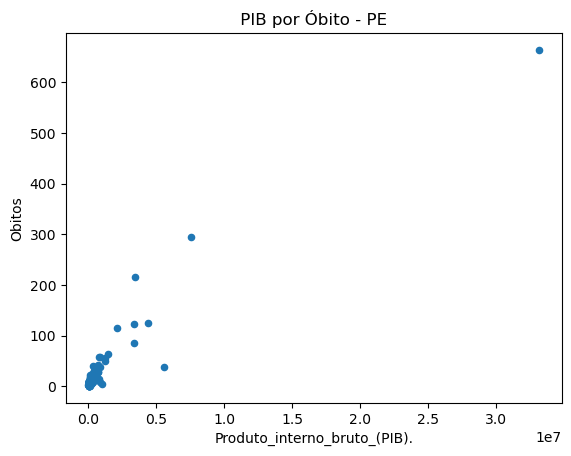

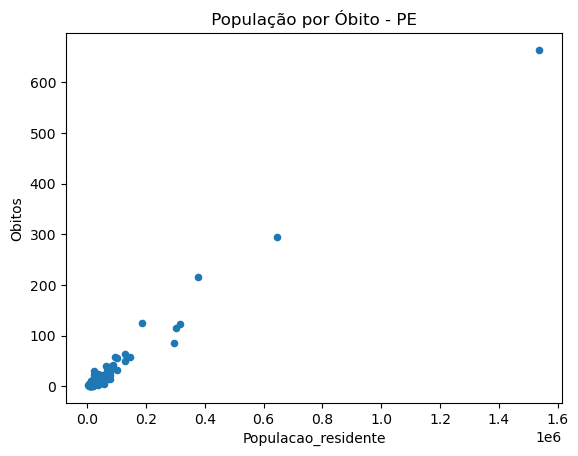

In [25]:
Pib_Obito_PE = Pib_Obito[Pib_Obito['Estado'] == 'PE']
Pib_Obito_PE.plot(kind = 'scatter', x = 'Produto_interno_bruto_(PIB).', y = 'Obitos', title = ' PIB por Óbito - PE ') 

Pop_Obito_PE = Pop_Obito[Pop_Obito['Estado'] == 'PE']
Pop_Obito_PE.plot(kind = 'scatter', x = 'Populacao_residente', y = 'Obitos', title = ' População por Óbito - PE ') 

<Axes: title={'center': ' População por Óbito - GO '}, xlabel='Populacao_residente', ylabel='Obitos'>

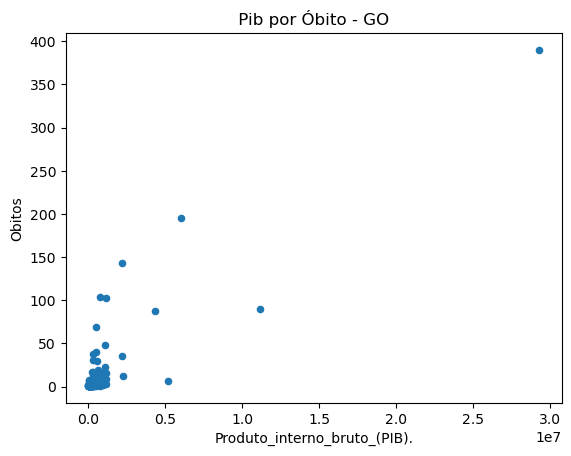

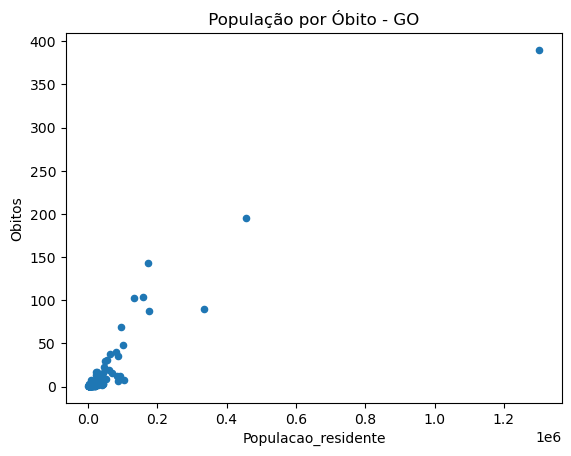

In [26]:
Pib_Obito_GO = Pib_Obito[Pib_Obito['Estado'] == 'GO']
Pib_Obito_GO.plot(kind = 'scatter', x = 'Produto_interno_bruto_(PIB).', y = 'Obitos', title = ' Pib por Óbito - GO ') 

Pop_Obito_GO = Pop_Obito[Pop_Obito['Estado'] == 'GO']
Pop_Obito_GO.plot(kind = 'scatter', x = 'Populacao_residente', y = 'Obitos', title = ' População por Óbito - GO ') 

<Axes: title={'center': ' População por Óbito - AC '}, xlabel='Populacao_residente', ylabel='Obitos'>

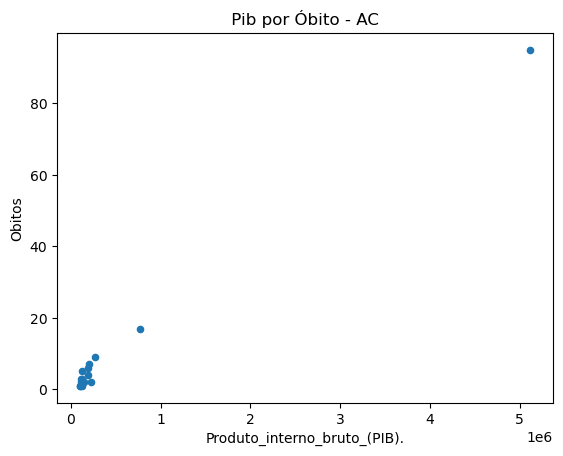

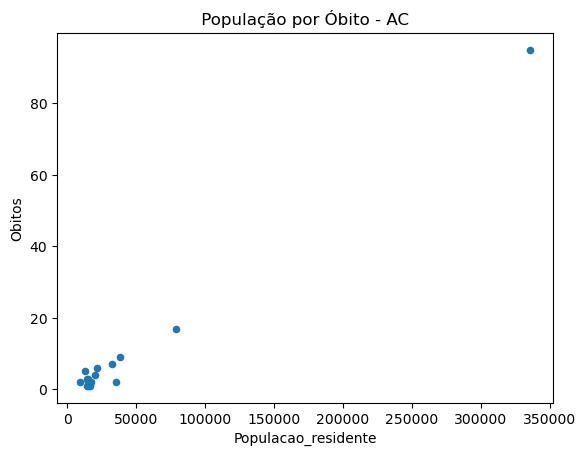

In [27]:
Pib_Obito_AC = Pib_Obito[Pib_Obito['Estado'] == 'AC']
Pib_Obito_AC.plot(kind = 'scatter', x = 'Produto_interno_bruto_(PIB).', y = 'Obitos', title = ' Pib por Óbito - AC ') 

Pop_Obito_AC = Pop_Obito[Pop_Obito['Estado'] == 'AC']
Pop_Obito_AC.plot(kind = 'scatter', x = 'Populacao_residente', y = 'Obitos', title = ' População por Óbito - AC ') 

In [28]:
Pib_Obito_AC_Padrao = Pib_Obito_AC.assign(Obito_Padrao = (Pib_Obito_AC['Obitos'] - Pib_Obito_AC['Obitos'].mean()) / np.std(Pib_Obito_AC['Obitos']))
Pib_Obito_AC_Padrao = Pib_Obito_AC_Padrao.assign(Pib_Padrao = (Pib_Obito_AC['Produto_interno_bruto_(PIB).'] - Pib_Obito_AC['Produto_interno_bruto_(PIB).'].mean()) / np.std(Pib_Obito_AC['Produto_interno_bruto_(PIB).']))

Pop_Obito_AC_Padrao = Pop_Obito_AC.assign(Obito_Padrao = (Pop_Obito_AC['Obitos'] - Pop_Obito_AC['Obitos'].mean()) / np.std(Pop_Obito_AC['Obitos']))
Pop_Obito_AC_Padrao = Pop_Obito_AC_Padrao.assign(Pop_Padrao = (Pop_Obito_AC['Populacao_residente'] - Pop_Obito_AC['Populacao_residente'].mean()) / np.std(Pop_Obito_AC['Populacao_residente']))

Pib_Obito_SC_Padrao = Pib_Obito_SC.assign(Obito_Padrao = (Pib_Obito_SC['Obitos'] - Pib_Obito_SC['Obitos'].mean()) / np.std(Pib_Obito_SC['Obitos']))
Pib_Obito_SC_Padrao = Pib_Obito_SC_Padrao.assign(Pib_Padrao = (Pib_Obito_SC['Produto_interno_bruto_(PIB).'] - Pib_Obito_SC['Produto_interno_bruto_(PIB).'].mean()) / np.std(Pib_Obito_SC['Produto_interno_bruto_(PIB).']))

Pop_Obito_SC_Padrao = Pop_Obito_SC.assign(Obito_Padrao = (Pop_Obito_SC['Obitos'] - Pop_Obito_SC['Obitos'].mean()) / np.std(Pop_Obito_SC['Obitos']))
Pop_Obito_SC_Padrao = Pop_Obito_SC_Padrao.assign(Pop_Padrao = (Pop_Obito_SC['Populacao_residente'] - Pop_Obito_SC['Populacao_residente'].mean()) / np.std(Pop_Obito_SC['Populacao_residente']))

Pib_Obito_ES_Padrao = Pib_Obito_ES.assign(Obito_Padrao = (Pib_Obito_ES['Obitos'] - Pib_Obito_ES['Obitos'].mean()) / np.std(Pib_Obito_ES['Obitos']))
Pib_Obito_ES_Padrao = Pib_Obito_ES_Padrao.assign(Pib_Padrao = (Pib_Obito_ES['Produto_interno_bruto_(PIB).'] - Pib_Obito_ES['Produto_interno_bruto_(PIB).'].mean()) / np.std(Pib_Obito_ES['Produto_interno_bruto_(PIB).']))

Pop_Obito_ES_Padrao = Pop_Obito_ES.assign(Obito_Padrao = (Pop_Obito_ES['Obitos'] - Pop_Obito_ES['Obitos'].mean()) / np.std(Pop_Obito_ES['Obitos']))
Pop_Obito_ES_Padrao = Pop_Obito_ES_Padrao.assign(Pop_Padrao = (Pop_Obito_ES['Populacao_residente'] - Pop_Obito_ES['Populacao_residente'].mean()) / np.std(Pop_Obito_ES['Populacao_residente']))

Pib_Obito_PE_Padrao = Pib_Obito_PE.assign(Obito_Padrao = (Pib_Obito_PE['Obitos'] - Pib_Obito_PE['Obitos'].mean()) / np.std(Pib_Obito_PE['Obitos']))
Pib_Obito_PE_Padrao = Pib_Obito_PE_Padrao.assign(Pib_Padrao = (Pib_Obito_PE['Produto_interno_bruto_(PIB).'] - Pib_Obito_PE['Produto_interno_bruto_(PIB).'].mean()) / np.std(Pib_Obito_PE['Produto_interno_bruto_(PIB).']))

Pop_Obito_PE_Padrao = Pop_Obito_PE.assign(Obito_Padrao = (Pop_Obito_PE['Obitos'] - Pop_Obito_PE['Obitos'].mean()) / np.std(Pop_Obito_PE['Obitos']))
Pop_Obito_PE_Padrao = Pop_Obito_PE_Padrao.assign(Pop_Padrao = (Pop_Obito_PE['Populacao_residente'] - Pop_Obito_PE['Populacao_residente'].mean()) / np.std(Pop_Obito_PE['Populacao_residente']))

Pib_Obito_GO_Padrao = Pib_Obito_GO.assign(Obito_Padrao = (Pib_Obito_GO['Obitos'] - Pib_Obito_GO['Obitos'].mean()) / np.std(Pib_Obito_GO['Obitos']))
Pib_Obito_GO_Padrao = Pib_Obito_GO_Padrao.assign(Pib_Padrao = (Pib_Obito_GO['Produto_interno_bruto_(PIB).'] - Pib_Obito_GO['Produto_interno_bruto_(PIB).'].mean()) / np.std(Pib_Obito_GO['Produto_interno_bruto_(PIB).']))

Pop_Obito_GO_Padrao = Pop_Obito_GO.assign(Obito_Padrao = (Pop_Obito_GO['Obitos'] - Pop_Obito_GO['Obitos'].mean()) / np.std(Pop_Obito_GO['Obitos']))
Pop_Obito_GO_Padrao = Pop_Obito_GO_Padrao.assign(Pop_Padrao = (Pop_Obito_GO['Populacao_residente'] - Pop_Obito_GO['Populacao_residente'].mean()) / np.std(Pop_Obito_GO['Populacao_residente']))

>$ C) $

In [29]:
estados_usados = ['ES', 'PE', 'GO', 'AC', 'SC']
merge = indicadores['ibge_sim'].merge(indicadores['ibge_populacao'])
merge = merge.assign(Estado = merge['ID'].apply(estadoID).apply(codigo_para_estado))
merge = merge.merge(indicadores['ibge_pib'])

X_pop = sm.add_constant(merge['Populacao_residente'])  
y = merge['Obitos']

modelo_pop = sm.OLS(y, X_pop).fit()

print("Regressão Linear: Óbitos vs População")
print(modelo_pop.summary())

X_pib = sm.add_constant(merge['Produto_interno_bruto_(PIB).']) 
y = merge['Obitos']

modelo_pib = sm.OLS(y, X_pib).fit()

print("Regressão Linear: Óbitos vs PIB")
print(modelo_pib.summary())


Regressão Linear: Óbitos vs População
                            OLS Regression Results                            
Dep. Variable:                 Obitos   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     7348.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:24:48   Log-Likelihood:                -18078.
No. Observations:                3560   AIC:                         3.616e+04
Df Residuals:                    3558   BIC:                         3.617e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

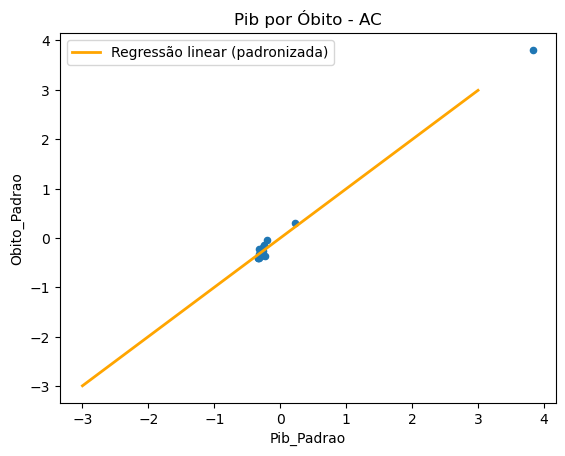

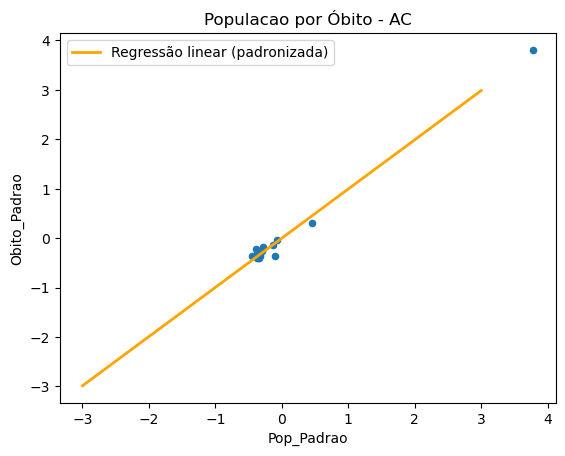

In [30]:
r_Pib_Obito_AC_Padrao = Pib_Obito_AC_Padrao['Obito_Padrao'].corr(Pib_Obito_AC_Padrao['Pib_Padrao'])
x = np.linspace(-3, 3) 
y1 = x * r_Pib_Obito_AC_Padrao
Pib_Obito_AC_Padrao.plot(kind='scatter', x='Pib_Padrao', y='Obito_Padrao', title='Pib por Óbito - AC')

plt.plot(x, y1, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()


r_Pop_Obito_AC_Padrao = Pop_Obito_AC_Padrao['Obito_Padrao'].corr(Pop_Obito_AC_Padrao['Pop_Padrao'])
Pop_Obito_AC_Padrao.plot(kind='scatter', x='Pop_Padrao', y='Obito_Padrao', title='Populacao por Óbito - AC')
y2 = x * r_Pop_Obito_AC_Padrao

plt.plot(x, y2, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()

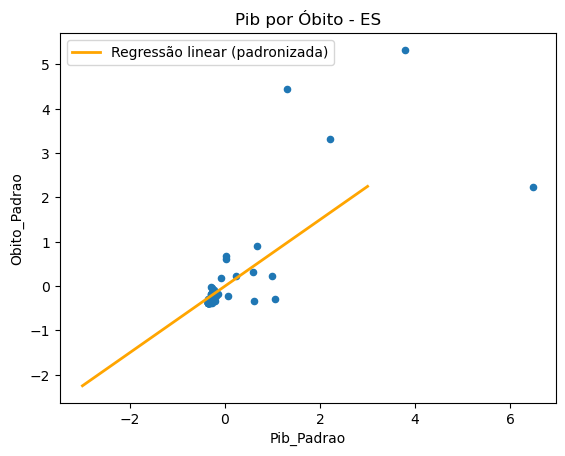

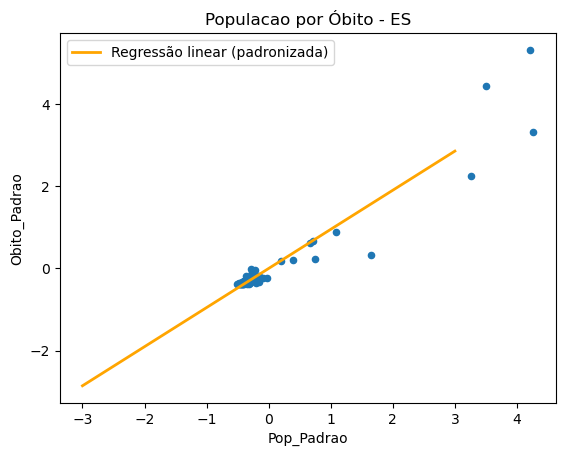

In [31]:
r_Pib_Obito_ES_Padrao = Pib_Obito_ES_Padrao['Obito_Padrao'].corr(Pib_Obito_ES_Padrao['Pib_Padrao'])
x = np.linspace(-3, 3) 
y1 = x * r_Pib_Obito_ES_Padrao
Pib_Obito_ES_Padrao.plot(kind='scatter', x='Pib_Padrao', y='Obito_Padrao', title='Pib por Óbito - ES')

plt.plot(x, y1, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()


r_Pop_Obito_ES_Padrao = Pop_Obito_ES_Padrao['Obito_Padrao'].corr(Pop_Obito_ES_Padrao['Pop_Padrao'])
Pop_Obito_ES_Padrao.plot(kind='scatter', x='Pop_Padrao', y='Obito_Padrao', title='Populacao por Óbito - ES')
y2 = x * r_Pop_Obito_ES_Padrao

plt.plot(x, y2, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()

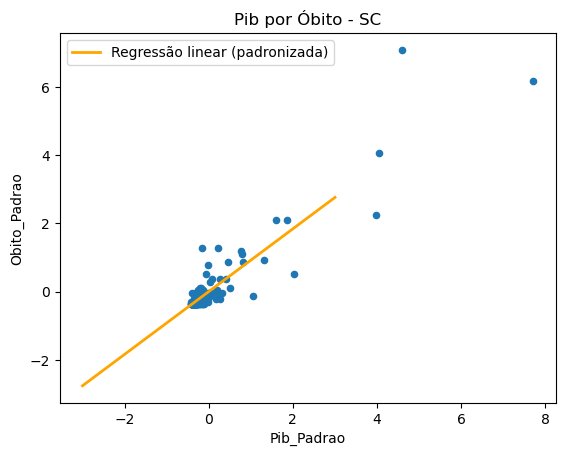

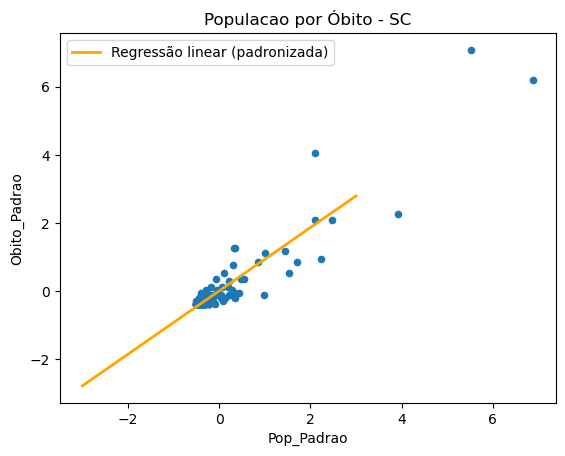

In [32]:
r_Pib_Obito_SC_Padrao = Pib_Obito_SC_Padrao['Obito_Padrao'].corr(Pib_Obito_SC_Padrao['Pib_Padrao'])
x = np.linspace(-3, 3) 
y1 = x * r_Pib_Obito_SC_Padrao
Pib_Obito_SC_Padrao.plot(kind='scatter', x='Pib_Padrao', y='Obito_Padrao', title='Pib por Óbito - SC')

plt.plot(x, y1, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()


r_Pop_Obito_SC_Padrao = Pop_Obito_SC_Padrao['Obito_Padrao'].corr(Pop_Obito_SC_Padrao['Pop_Padrao'])
Pop_Obito_SC_Padrao.plot(kind='scatter', x='Pop_Padrao', y='Obito_Padrao', title='Populacao por Óbito - SC')
y2 = x * r_Pop_Obito_SC_Padrao

plt.plot(x, y2, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()

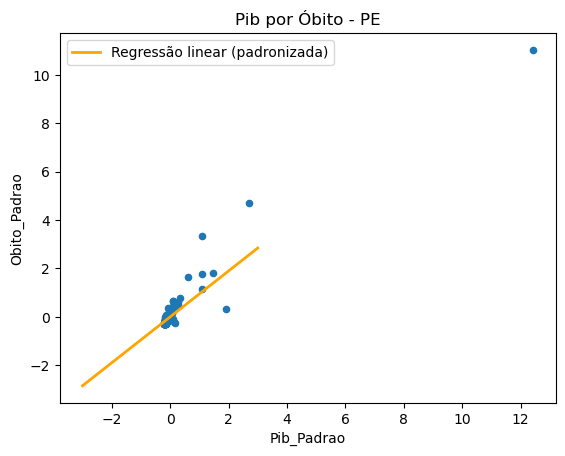

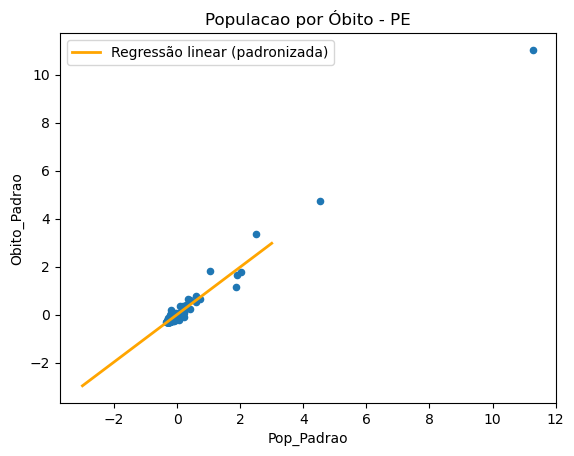

In [33]:
r_Pib_Obito_PE_Padrao = Pib_Obito_PE_Padrao['Obito_Padrao'].corr(Pib_Obito_PE_Padrao['Pib_Padrao'])
x = np.linspace(-3, 3) 
y1 = x * r_Pib_Obito_PE_Padrao
Pib_Obito_PE_Padrao.plot(kind='scatter', x='Pib_Padrao', y='Obito_Padrao', title='Pib por Óbito - PE')

plt.plot(x, y1, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()


r_Pop_Obito_PE_Padrao = Pop_Obito_PE_Padrao['Obito_Padrao'].corr(Pop_Obito_PE_Padrao['Pop_Padrao'])
Pop_Obito_PE_Padrao.plot(kind='scatter', x='Pop_Padrao', y='Obito_Padrao', title='Populacao por Óbito - PE')
y2 = x * r_Pop_Obito_PE_Padrao

plt.plot(x, y2, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()

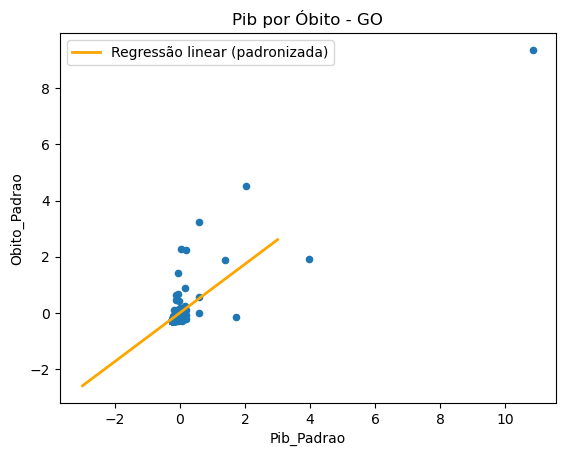

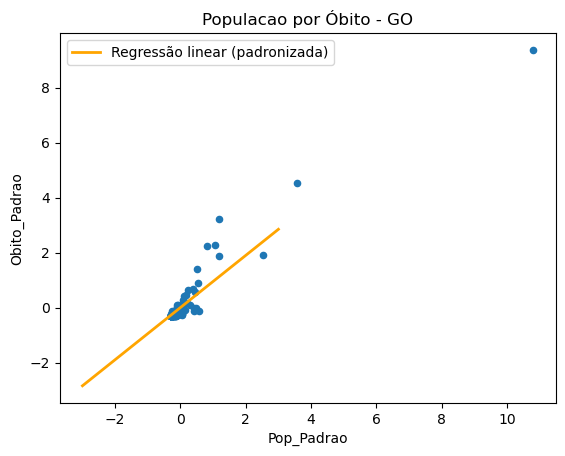

In [34]:
r_Pib_Obito_GO_Padrao = Pib_Obito_GO_Padrao['Obito_Padrao'].corr(Pib_Obito_GO_Padrao['Pib_Padrao'])
x = np.linspace(-3, 3) 
y1 = x * r_Pib_Obito_GO_Padrao
Pib_Obito_GO_Padrao.plot(kind='scatter', x='Pib_Padrao', y='Obito_Padrao', title='Pib por Óbito - GO')

plt.plot(x, y1, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()


r_Pop_Obito_GO_Padrao = Pop_Obito_GO_Padrao['Obito_Padrao'].corr(Pop_Obito_GO_Padrao['Pop_Padrao'])
Pop_Obito_GO_Padrao.plot(kind='scatter', x='Pop_Padrao', y='Obito_Padrao', title='Populacao por Óbito - GO')
y2 = x * r_Pop_Obito_GO_Padrao

plt.plot(x, y2, color='orange', lw=2, label='Regressão linear (padronizada)')
plt.legend()
plt.show()

>$ D)$ O resultado obtido indica que quanto maior o PIB, maior a quantidade de óbitos. Por mais que pareça errado, o que justifica é que os óbitos são em número absoluto, logo as cidades com maior PIB possuem maior população e consequentemente mais óbitos


In [35]:
# Merge PIB, População e Óbitos
df_merge = indicadores['ibge_sim'][['ID', 'Obitos']].merge(
    indicadores['ibge_pib'][['ID', 'Produto_interno_bruto_(PIB).']],
    on='ID'
).merge(
    indicadores['ibge_populacao'][['ID', 'Populacao_residente']],
    on='ID'
)

# Renomear para facilitar
df_merge.columns = ['ID', 'Obitos', 'PIB', 'Populacao']

# Regressão Múltipla
X = df_merge[['PIB', 'Populacao']]
X = sm.add_constant(X)
y = df_merge['Obitos']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                 Obitos   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     7422.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:24:50   Log-Likelihood:                -17146.
No. Observations:                3560   AIC:                         3.430e+04
Df Residuals:                    3557   BIC:                         3.432e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9030      0.528     -7.386      0.0

O PIB está correlacionado com população, não sendo significativo na previsão de óbitos